In [1]:
import sqlite3

# Connect to the SQLite database (will create if it doesn't exist)
conn = sqlite3.connect("sales_data.db")


In [2]:
cursor = conn.cursor()

# Create a simple sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sample_data = [
    ("Apple", 10, 0.5),
    ("Banana", 5, 0.2),
    ("Orange", 8, 0.3),
    ("Apple", 7, 0.5),
    ("Banana", 10, 0.2),
    ("Orange", 4, 0.3)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()


In [3]:
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""


In [4]:
import pandas as pd

# Load the SQL query result into a DataFrame
df = pd.read_sql_query(query, conn)


In [5]:
print(df)


  product  total_qty  revenue
0   Apple         17      8.5
1  Banana         15      3.0
2  Orange         12      3.6


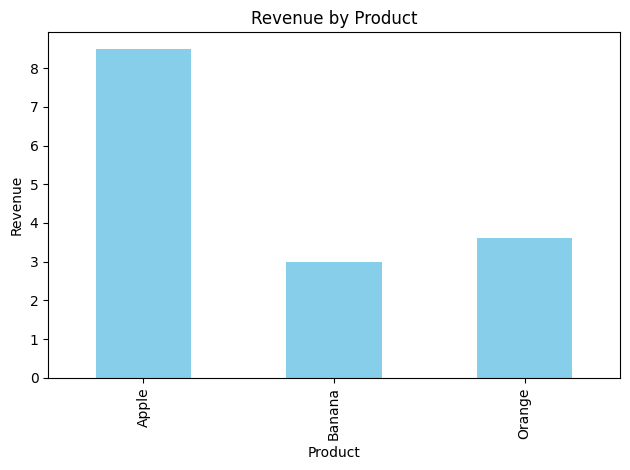

In [6]:
import matplotlib.pyplot as plt

# Create a bar chart
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


In [7]:
# Save chart as image file
plt.savefig("sales_chart.png")


<Figure size 640x480 with 0 Axes>